# Four-target SFP: single-route versus multi-route training

完整的训练、断点续训和验证 notebook。先运行之前的多路线数据构建 notebook，然后将本文件放在
`streaming-flow-policy` 仓库内，使用原来安装了 PyTorch 的 Python 环境，从上到下运行。

**主实验：** 同样的 10,000 个训练布局、原网络、优化器和训练更新预算；只改变每次监督采样时选择的专家路线。
- `single`：沿用 v1 的唯一最优专家路线；`multi`：均匀选布局，再均匀选该布局的一条近优路线。
- 默认 5,000 epochs，五个配对种子 0–4；可先设 `SEEDS=[0]` 跑一对试验，再补其他种子。
- 每个 epoch 仍是 100 次更新，每次 2,048 个样本，**不是遍历全部路线一遍**。
- 主比较使用 `final.pt`（训练到预算末尾），不按单路线验证 MSE 选择多路线模型。
- 若旧实验有设置完全匹配、已训练到预算末尾的 `latest.pt` / `final.pt`，可复用为 single 对照。
  `best.pt` 不会用于替代末轮对照；旧文件不会被修改。
- 全部 1,000 个验证布局，固定精确起点，float64 RK4 1,000 步；成功以到达四个目标判断，不要求指定访问顺序。
  主阈值 0.02，辅助阈值 0.05；测试集不读取。
- 同一布局和精确起点的推理是确定性的。本实验不使用多次采样取最好结果，也不声称已验证多模态生成能力。

训练配置不同会拒绝混用已有运行。需要改超参数时，请更换 `EXPERIMENT_TAG`；增加种子不需要换。
这里默认从头训练新的 multi 模型，不从旧 single 权重微调。


In [12]:
from pathlib import Path
import copy, hashlib, itertools, json, os, platform, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import display

PROJECT_ROOT_OVERRIDE = None   # e.g. Path(r'D:/projects/streaming-flow-policy')
MULTIROUTE_FOLDER = 'v2_nearopt_05pct'
EXPERIMENT_TAG = 'single_vs_multi_05pct_v1'
BUDGETS = [10000]
SEEDS = [0]        # Pilot: [0]. Later expand and rerun; completed runs are reused.
MODES = ['single', 'multi']
REUSE_OLD_FINAL_BASELINES = True
CHECKPOINT_EVERY = 25           # Resume from last saved complete epoch; at most 24 complete epochs lost
PROBE_EVERY = 25                # Fixed single-expert validation MSE, diagnostic only
EVAL_STEPS = 1000
EVAL_BATCH_SIZE = 100
VISIT_TOLERANCES = [0.02, 0.05]
PLOT_SEED = SEEDS[0]            # Preselected, not the highest-performing seed

def find_root():
    if PROJECT_ROOT_OVERRIDE is not None:
        return Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
    here = Path.cwd().resolve()
    for root in [here, *here.parents]:
        if (root/'experiments/four_boxes_experiments/four_targets/datasets/v1/train.npz').is_file():
            return root
    raise FileNotFoundError('Run inside the repository, or set PROJECT_ROOT_OVERRIDE.')

PROJECT_ROOT = find_root()
TASK_ROOT = PROJECT_ROOT/'experiments/four_boxes_experiments/four_targets'
V1_DIR = TASK_ROOT/'datasets/v1'
MULTI_DIR = TASK_ROOT/'datasets'/MULTIROUTE_FOLDER
RUN_ROOT = TASK_ROOT/'runs'/EXPERIMENT_TAG
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_CONFIG = dict(input_preprocessing='sort_targets_by_x_then_y',
    num_training_layouts=10000, validation_probe_seed=500, validation_probe_size=20000,
    steps_per_epoch=100, batch_size=2048, learning_rate=1e-3, weight_decay=1e-6,
    hidden_dim=128, num_hidden_layers=4, sigma_0=0.05, stabilizing_gain=2.5)
assert len(set(SEEDS)) == len(SEEDS) and SEEDS and all(isinstance(s, int) and s >= 0 for s in SEEDS)
assert len(set(BUDGETS)) == len(BUDGETS) and BUDGETS and all(isinstance(b, int) and b > 0 for b in BUDGETS)
assert MODES and len(set(MODES)) == len(MODES) and set(MODES) <= {'single', 'multi'}
assert CHECKPOINT_EVERY > 0 and PROBE_EVERY > 0 and EVAL_STEPS > 0 and EVAL_BATCH_SIZE > 0
assert 0.02 in VISIT_TOLERANCES and 0.05 in VISIT_TOLERANCES
assert len(set(VISIT_TOLERANCES)) == len(VISIT_TOLERANCES)
print('Project:', PROJECT_ROOT, '\nDevice:', DEVICE, '\nOutput:', RUN_ROOT)
print('Requested runs:', len(BUDGETS)*len(SEEDS)*len(MODES))
print('Updates per model:', {b: b*BASE_CONFIG['steps_per_epoch'] for b in BUDGETS})
if DEVICE.type == 'cpu':
    print('CUDA is unavailable. Full training on CPU can be slow; check the selected notebook kernel.')


Project: /home/u7779895/PycharmProjects/streaming-flow-policy_new 
Device: cuda 
Output: /home/u7779895/PycharmProjects/streaming-flow-policy_new/experiments/four_boxes_experiments/four_targets/runs/single_vs_multi_05pct_v1
Requested runs: 2
Updates per model: {10000: 1000000}


## 1. Load and verify the fixed data
v2 必须来自当前 v1；原始布局和单路线字段逐项核对。不会重建布局，也不会把验证数据加入训练。


In [13]:
def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda: f.read(1024*1024), b''):
            h.update(block)
    return h.hexdigest()

def load_npz(path):
    with np.load(path, allow_pickle=False) as z:
        return {k: z[k].copy() for k in z.files}

def validate_single_split(split, expected_n):
    n = len(split['targets'])
    if n != expected_n:
        raise ValueError(f'Expected {expected_n} layouts, got {n}')
    for key, shape in dict(starts=(n,2), targets=(n,4,2), conditions=(n,10),
                           routes=(n,5,2), knot_tau=(n,5), lengths=(n,)).items():
        if split[key].shape != shape or not np.isfinite(split[key]).all():
            raise ValueError(f'Invalid {key}')
    assert np.all(np.diff(split['knot_tau'], axis=1) > 0)
    assert np.all(split['lengths'] > 0)
    np.testing.assert_allclose(split['knot_tau'][:,0], 0, atol=1e-7)
    np.testing.assert_allclose(split['knot_tau'][:,-1], 1, atol=1e-7)
    np.testing.assert_array_equal(split['conditions'], np.concatenate(
        [split['starts'], split['targets'].reshape(n,8)], axis=1))
    np.testing.assert_array_equal(split['routes'][:,0], split['starts'])

single_train = load_npz(V1_DIR/'train.npz')
validation = load_npz(V1_DIR/'validation.npz')
multi_train = load_npz(MULTI_DIR/'train.npz')
build_config = json.loads((MULTI_DIR/'config.json').read_text(encoding='utf-8'))
validate_single_split(single_train, 10000)
validate_single_split(validation, 1000)
for k, v in single_train.items():
    np.testing.assert_array_equal(v, multi_train[k], err_msg=f'v1/v2 mismatch: {k}')
    assert v.dtype == multi_train[k].dtype
DATA_HASHES = {'train.npz': sha256_file(V1_DIR/'train.npz'),
               'validation.npz': sha256_file(V1_DIR/'validation.npz')}
MULTI_HASH = sha256_file(MULTI_DIR/'train.npz')
assert build_config['source_train_sha256'] == DATA_HASHES['train.npz'], 'v2 has a different v1 source'
assert np.isclose(build_config['relative_slack'], 0.05, rtol=0, atol=1e-12), 'Expected 5% candidate slack'
assert build_config['artifact_sha256']['train.npz'] == MULTI_HASH, 'v2 file changed since construction'
counts, offsets = multi_train['num_modes'], multi_train['mode_offsets']
assert counts.shape == (10000,) and np.issubdtype(counts.dtype, np.integer)
assert offsets.shape == (10001,) and np.issubdtype(offsets.dtype, np.integer)
assert np.all((counts >= 1) & (counts <= 24))
np.testing.assert_array_equal(np.diff(offsets), counts)
assert offsets[0] == 0 and offsets[-1] == len(multi_train['mode_routes'])
assert np.isfinite(multi_train['mode_routes']).all()
assert np.isfinite(multi_train['mode_knot_tau']).all()
assert np.all(np.diff(multi_train['mode_knot_tau'], axis=1) > 0)
np.testing.assert_allclose(multi_train['mode_knot_tau'][:,0], 0, atol=1e-12)
np.testing.assert_allclose(multi_train['mode_knot_tau'][:,-1], 1, atol=1e-12)
np.testing.assert_allclose(validation['starts'], np.broadcast_to(single_train['starts'][0], (1000,2)))
print(f'Train: {len(counts):,} layouts, {counts.sum():,} expert routes; validation: 1,000 layouts.')
print(f'Multiple-route layouts: {100*np.mean(counts>1):.2f}%')
print('Test split not loaded.')


Train: 10,000 layouts, 16,302 expert routes; validation: 1,000 layouts.
Multiple-route layouts: 43.06%
Test split not loaded.


## 2. Original network and layout-balanced sampler
网络与原 notebook 相同。单次样本只选一条完整专家路线，再采样时间和噪声；不平均路线。
模型输入仍为 13 维，路线编号和访问顺序不作为输入。


In [14]:
def canonicalize_box_inputs(inputs):
    boxes = inputs[:, 5:].reshape(-1, 4, 2)
    for coordinate in [1, 0]:  # secondary y key, then primary x key
        order = torch.argsort(boxes[:, :, coordinate], dim=1, stable=True)
        boxes = torch.gather(boxes, 1, order.unsqueeze(-1).expand(-1, -1, 2))
    return torch.cat([inputs[:, :5], boxes.reshape(-1, 8)], dim=1)

class CanonicalConditionalVelocityMLP(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        width = 13
        for _ in range(4):
            layers.extend([nn.Linear(width, 128), nn.SiLU()])
            width = 128
        layers.append(nn.Linear(width, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(2.0 * canonicalize_box_inputs(inputs) - 1.0)

def sample_training_batch(split, batch_size, rng, config, sampling='multi', return_info=False):
    if sampling not in ('single', 'multi'):
        raise ValueError("sampling must be 'single' or 'multi'")
    if batch_size <= 0:
        raise ValueError('batch_size must be positive')
    sigma_0 = float(config['sigma_0'])
    gain = float(config['stabilizing_gain'])
    if not np.isfinite([sigma_0, gain]).all() or sigma_0 <= 0 or gain < 0:
        raise ValueError('Require finite sigma_0 > 0 and stabilizing_gain >= 0')
    n = len(split['targets'])
    layout_indices = rng.integers(0, n, size=batch_size)
    if sampling == 'multi':
        # Each draw has its own upper bound, so every route within the chosen layout is equiprobable.
        mode_local_indices = rng.integers(0, split['num_modes'][layout_indices], size=batch_size)
        route_indices = split['mode_offsets'][layout_indices] + mode_local_indices
        routes = split['mode_routes'][route_indices]
        knots = split['mode_knot_tau'][route_indices]
    else:
        route_indices = np.full(batch_size, -1, dtype=np.int64)
        routes = split['routes'][layout_indices]
        knots = split['knot_tau'][layout_indices]
    tau = rng.uniform(0.0, 1.0, size=batch_size)
    segments = np.clip((tau[:, None] >= knots[:, 1:]).sum(axis=1), 0, 3)
    row = np.arange(batch_size)
    p0 = routes[row, segments]
    p1 = routes[row, segments + 1]
    t0 = knots[row, segments]
    duration = knots[row, segments + 1] - t0
    if np.any(duration <= 0):
        raise ValueError('Expert route contains a non-positive-duration segment')
    positions = p0 + ((tau - t0) / duration)[:, None] * (p1 - p0)
    derivatives = (p1 - p0) / duration[:, None]
    offsets = (sigma_0 * np.exp(-gain * tau))[:, None] * rng.standard_normal((batch_size, 2))
    actions = positions + offsets
    velocity_targets = derivatives - gain * offsets
    inputs = np.concatenate([actions, tau[:, None], split['conditions'][layout_indices]], axis=1)
    inputs = inputs.astype(np.float32)
    velocity_targets = velocity_targets.astype(np.float32)
    if return_info:
        return inputs, velocity_targets, {
            'layout_indices': layout_indices, 'route_indices': route_indices,
            'tau': tau, 'expert_positions': positions, 'expert_derivatives': derivatives,
            'offsets': offsets,
        }
    return inputs, velocity_targets


## 3. Training helpers and checkpoint compatibility
同一个 seed 的两组使用相同初始化种子。multi 多了路线抽样，因此两组的 NumPy 随机流不会逐样本完全相同。
保存完整的模型、优化器、scheduler 和随机状态；在相同运行环境下可从保存点接着训练。
验证探针只用于观察，依旧参考单条专家，因此它对多路线模型有偏向，不能用它判断谁更好。


In [15]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def atomic_json(value, path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix+'.tmp')
    tmp.write_text(json.dumps(value, indent=2, ensure_ascii=False, allow_nan=False), encoding='utf-8')
    os.replace(tmp, path)

def atomic_save(value, path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix+'.tmp')
    torch.save(value, tmp)
    os.replace(tmp, path)

def cpu_state(model):
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

@torch.no_grad()
def probe_mse(model, x, y):
    model.eval()
    total = 0.0
    for start in range(0, len(x), 4096):
        loss = nn.functional.mse_loss(model(x[start:start+4096]), y[start:start+4096])
        if not torch.isfinite(loss):
            raise RuntimeError('Non-finite validation probe')
        total += loss.item()*len(x[start:start+4096])
    return total/len(x)

def make_config(budget, seed, mode):
    return {**BASE_CONFIG, 'implementation_version': 'single_multi_train_v1',
        'training_seed': int(seed), 'train_sampling_seed': int(1000+seed),
        'num_epochs': int(budget), 'sampling': mode, 'dataset_sha256': DATA_HASHES,
        'multiroute_sha256': MULTI_HASH, 'relative_slack': 0.05,
        'checkpoint_every': CHECKPOINT_EVERY, 'probe_every': PROBE_EVERY,
        'selection': 'final_epoch', 'sampler_sha256': SAMPLER_SHA256}

def assert_same_config(saved, current):
    if saved != current:
        diffs = {k: [saved.get(k), current.get(k)] for k in set(saved)|set(current)
                 if saved.get(k) != current.get(k)}
        raise ValueError('Run config changed; use another EXPERIMENT_TAG. Differences: '+str(diffs))

def old_final_baseline(budget, seed):
    if not REUSE_OLD_FINAL_BASELINES:
        return None
    dirs = [TASK_ROOT/'runs/conditional_mlp_canonical_seed_sweep'/f'budget_{budget}_seed_{seed}']
    if seed == 0:
        dirs.append(TASK_ROOT/'runs'/f'conditional_mlp_canonical_{budget}epochs_v1_seed0')
    expected = {**BASE_CONFIG, 'training_seed': seed, 'train_sampling_seed': 1000+seed,
                'num_epochs': budget, 'dataset_sha256': DATA_HASHES}
    for directory in dirs:
        for name in ['final.pt', 'latest.pt']:
            path = directory/name
            if not path.is_file():
                continue
            ckpt = torch.load(path, map_location='cpu', weights_only=True)
            cfg = ckpt.get('config', {})
            mismatch = [k for k,v in expected.items() if cfg.get(k) != v]
            if ckpt.get('epoch') != budget or mismatch or 'model' not in ckpt:
                print('[old baseline skipped]', path, 'epoch=', ckpt.get('epoch'), 'different:', mismatch)
                continue
            # Also verify the architecture, not only the configuration.
            test_model = CanonicalConditionalVelocityMLP()
            test_model.load_state_dict(ckpt['model'], strict=True)
            del test_model
            return path, ckpt
    return None

def train_or_resume(budget, seed, mode):
    config = make_config(budget, seed, mode)
    run_dir = RUN_ROOT/f'budget_{budget}_seed_{seed}_{mode}'
    run_dir.mkdir(parents=True, exist_ok=True)
    config_path = run_dir/'config.json'
    if config_path.exists():
        assert_same_config(json.loads(config_path.read_text(encoding='utf-8')), config)
    else:
        atomic_json(config, config_path)
    latest, final = run_dir/'latest.pt', run_dir/'final.pt'
    if final.exists():
        ckpt = torch.load(final, map_location='cpu', weights_only=True)
        assert_same_config(ckpt['config'], config)
        assert ckpt['epoch'] == budget
        print(f'[complete] {budget=} {seed=} {mode=}')
        return run_dir
    if mode == 'single' and not latest.exists():
        old = old_final_baseline(budget, seed)
        if old is not None:
            source_path, ckpt = old
            atomic_save({'model': ckpt['model'], 'epoch': budget, 'config': config,
                'history': ckpt.get('history', {}),
                'provenance': {'source': source_path.relative_to(PROJECT_ROOT).as_posix(),
                               'sha256': sha256_file(source_path), 'reused_old_final': True}}, final)
            print('[reuse final baseline]', source_path)
            return run_dir

    set_seed(seed)
    model = CanonicalConditionalVelocityMLP().to(device=DEVICE, dtype=torch.float32)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'],
                                  weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=budget)
    train_rng = np.random.default_rng(config['train_sampling_seed'])
    vx, vy = sample_training_batch(validation, config['validation_probe_size'],
        np.random.default_rng(config['validation_probe_seed']), config, sampling='single')
    vx, vy = torch.from_numpy(vx).to(DEVICE), torch.from_numpy(vy).to(DEVICE)
    history = {'epoch': [], 'train_loss': [], 'probe_epoch': [], 'single_expert_probe_mse': []}
    start_epoch = 0
    if latest.exists():
        ckpt = torch.load(latest, map_location='cpu', weights_only=True)
        assert_same_config(ckpt['config'], config)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        train_rng.bit_generator.state = ckpt['numpy_rng_state']
        random.setstate(ckpt['python_rng_state'])
        torch.set_rng_state(ckpt['torch_rng_state'])
        states = ckpt['cuda_rng_states']
        if DEVICE.type == 'cuda' and states:
            if len(states) == torch.cuda.device_count():
                torch.cuda.set_rng_state_all(states)
            else:
                print('GPU count changed: exact CUDA RNG replay is unavailable.')
        history, start_epoch = ckpt['history'], ckpt['epoch']
        if not 0 <= start_epoch <= budget:
            raise ValueError('Invalid saved epoch')
        del ckpt
    atomic_json({'python': platform.python_version(), 'numpy': np.__version__,
        'torch': str(torch.__version__), 'device': str(DEVICE),
        'gpu': torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else None}, run_dir/'environment.json')
    print(f'[train] {mode}, seed {seed}, epochs {start_epoch} -> {budget}', flush=True)
    start_time = time.monotonic()
    for epoch in range(start_epoch+1, budget+1):
        model.train()
        loss_sum = 0.0
        for _ in range(config['steps_per_epoch']):
            x, y = sample_training_batch(multi_train, config['batch_size'], train_rng, config, sampling=mode)
            x, y = torch.from_numpy(x).to(DEVICE), torch.from_numpy(y).to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = nn.functional.mse_loss(model(x), y)
            if not torch.isfinite(loss):
                raise RuntimeError('Non-finite training loss; last complete checkpoint is preserved.')
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
        history['epoch'].append(epoch)
        history['train_loss'].append(loss_sum/config['steps_per_epoch'])
        if epoch == 1 or epoch % PROBE_EVERY == 0 or epoch == budget:
            val_loss = probe_mse(model, vx, vy)
            history['probe_epoch'].append(epoch)
            history['single_expert_probe_mse'].append(val_loss)
            elapsed = time.monotonic()-start_time
            eta = elapsed/(epoch-start_epoch)*(budget-epoch)
            print(f'{mode} seed={seed} epoch={epoch}/{budget} train={history["train_loss"][-1]:.6f} '
                  f'single-probe={val_loss:.6f} ETA={eta/3600:.2f}h', flush=True)
        # Match the original schedule: one scheduler step after each complete epoch.
        scheduler.step()
        if epoch % CHECKPOINT_EVERY == 0 or epoch == budget:
            atomic_save({'model': cpu_state(model), 'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(), 'epoch': epoch, 'config': config,
                'history': history, 'numpy_rng_state': train_rng.bit_generator.state,
                'python_rng_state': random.getstate(), 'torch_rng_state': torch.get_rng_state(),
                'cuda_rng_states': torch.cuda.get_rng_state_all() if DEVICE.type == 'cuda' else []}, latest)
            atomic_json(history, run_dir/'history.json')
    atomic_save({'model': cpu_state(model), 'epoch': budget, 'config': config,
                 'history': history, 'provenance': {'reused_old_final': False}}, final)
    del model, optimizer, scheduler, vx, vy
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return run_dir


In [16]:
SAMPLER_SHA256 = '541e436859407bb559ba3876dbb09ec2efa42f2226ae7c40696d5efa4255feee'
print('Training functions ready.')


Training functions ready.


## 4. Run training (long-running cell)
首次执行会训练所需模型；再次运行会跳过已完成的模型，继续未完成的模型。
默认检查点间隔为 25 epochs；中断后会从最近的完整检查点继续，不会保存半个 epoch 的状态。
要迁移机器，请连同数据和整个对应 runs 文件夹一起迁移，绝对路径不参与配置身份判断。
改变总预算意味着新的 cosine schedule，故 5,000 和 10,000 是独立训练，不能把前者直接续成后者。


In [17]:
run_records = {}
for budget in BUDGETS:
    for seed in SEEDS:
        for mode in MODES:
            run_records[(budget, seed, mode)] = train_or_resume(budget, seed, mode)
print('All requested final checkpoints are ready.')


[complete] budget=10000 seed=0 mode='single'
[complete] budget=10000 seed=0 mode='multi'
All requested final checkpoints are ready.


## 5. Evaluation functions
同一模型对每个验证布局只生成一次轨迹，并用这条轨迹同时计算 0.02 和 0.05 的成功率。
距离按目标到整条折线的最短距离计算，包含线段内部，而非只检查离散采样点。

`gap_percent` 是验证布局的第二短专家与最短专家之间的相对长度差，不是模型轨迹误差。
`path_length_ratio` 是模型完整轨迹长度 / 目标中心的精确最短长度；因允许擦到目标圆，它可能小于 1。
`order_excess_percent` 根据首次进入目标圆的顺序，重新连接四个目标中心后计算长度超额，
只对成功轨迹有定义。同一时刻进入多个圆的情况标记为 ambiguous，不纳入访问顺序质量均值。
这些长度指标辅助解释结果，不参与成功判定。


In [18]:
@torch.no_grad()
def generate_paths(model, split, num_steps=1000, batch_size=100):
    parameter = next(model.parameters())
    outputs = []
    model.eval()
    dt = 1.0/num_steps
    for lo in range(0, len(split['starts']), batch_size):
        hi = min(lo+batch_size, len(split['starts']))
        conditions = torch.as_tensor(split['conditions'][lo:hi], dtype=parameter.dtype, device=parameter.device)
        actions = torch.as_tensor(split['starts'][lo:hi], dtype=parameter.dtype, device=parameter.device).clone()
        paths = np.empty((hi-lo, num_steps+1, 2), dtype=np.float64)
        paths[:,0] = actions.cpu().numpy()
        def velocity(a, tau):
            t = torch.full((len(a),1), tau, dtype=a.dtype, device=a.device)
            return model(torch.cat([a,t,conditions], dim=1))
        for step in range(num_steps):
            tau = step*dt
            k1 = velocity(actions, tau)
            k2 = velocity(actions+dt*k1/2, tau+dt/2)
            k3 = velocity(actions+dt*k2/2, tau+dt/2)
            k4 = velocity(actions+dt*k3, min(tau+dt,1.0))
            actions = actions + dt/6*(k1+2*k2+2*k3+k4)
            paths[:,step+1] = actions.cpu().numpy()
        if not np.isfinite(paths).all():
            raise RuntimeError('Non-finite rollout')
        outputs.append(paths)
        print(f'  rollout {hi}/{len(split["starts"])}', flush=True)
    return np.concatenate(outputs)

def target_distances(path, targets):
    p0, v = path[:-1], np.diff(path, axis=0)
    w = targets[:,None,:]-p0[None,:,:]
    denom = np.maximum(np.sum(v*v,axis=1), 1e-30)
    u = np.clip(np.sum(w*v[None,:,:],axis=2)/denom[None,:],0,1)
    closest = p0[None,:,:]+u[:,:,None]*v[None,:,:]
    return np.linalg.norm(targets[:,None,:]-closest,axis=2).min(axis=1)

def exact_route_lengths(split):
    all_lengths = []
    for order in itertools.permutations(range(4)):
        vertices = np.concatenate([split['starts'][:,None,:],split['targets'][:,order,:]],axis=1)
        all_lengths.append(np.linalg.norm(np.diff(vertices,axis=1),axis=2).sum(axis=1))
    ordered = np.sort(np.stack(all_lengths,axis=1),axis=1)
    return ordered[:,0], 100*(ordered[:,1]-ordered[:,0])/ordered[:,0]

def first_entry_times(path, targets, radius):
    # Solve segment-circle intersections, including endpoints and stationary segments.
    p0, v = path[:-1], np.diff(path,axis=0)
    a = np.sum(v*v,axis=1)
    result = np.full(len(targets), np.inf)
    for j, target in enumerate(targets):
        d = p0-target
        b = 2*np.sum(d*v,axis=1)
        c = np.sum(d*d,axis=1)-radius**2
        discriminant = b*b-4*a*c
        moving = a > 1e-30
        root = np.sqrt(np.maximum(discriminant,0))
        denom = np.where(moving,2*a,1.0)
        enter, leave = (-b-root)/denom, (-b+root)/denom
        hit = moving & (discriminant >= 0) & (leave >= 0) & (enter <= 1)
        u = np.where(c <= 0, 0.0, np.where(hit,np.clip(enter,0,1),np.inf))
        result[j] = np.min(np.arange(len(v))+u)/(len(path)-1)
    return result

GAP_LABELS = ['<1%', '1–<5%', '5–<10%', '≥10%']
def gap_labels(gap):
    return np.asarray(GAP_LABELS)[np.searchsorted([1.0,5.0,10.0], gap, side='right')]

def evaluate_arrays(paths, split, budget, seed, mode):
    distances = np.stack([target_distances(p,t) for p,t in zip(paths,split['targets'])])
    optimal, gaps = exact_route_lengths(split)
    np.testing.assert_allclose(split['lengths'], optimal, rtol=2e-6, atol=1e-7)
    path_lengths = np.linalg.norm(np.diff(paths,axis=1),axis=2).sum(axis=1)
    frames = []
    for tol in VISIT_TOLERANCES:
        visited = (distances <= tol).sum(axis=1)
        success = visited == 4
        excess = np.full(len(paths),np.nan)
        ambiguous = np.zeros(len(paths),dtype=bool)
        orders = np.full((len(paths),4),-1,dtype=np.int64)
        for i in np.flatnonzero(success):
            hits = first_entry_times(paths[i],split['targets'][i],tol)
            if not np.isfinite(hits).all():
                # Preserve success metric; only order extraction is numerically unresolved.
                ambiguous[i] = True
                continue
            order = np.argsort(hits,kind='stable')
            orders[i] = order
            ambiguous[i] = bool(np.any(np.diff(hits[order]) <= 1e-10))
            if not ambiguous[i]:
                vertices = np.concatenate([split['starts'][i,None,:],split['targets'][i,order]],axis=0)
                length = np.linalg.norm(np.diff(vertices,axis=0),axis=1).sum()
                excess[i] = max(0.0,100*(length/optimal[i]-1))
        frame = pd.DataFrame(dict(budget=budget,seed=seed,mode=mode,tolerance=tol,
            layout_index=np.arange(len(paths)),visited_count=visited,success=success,
            worst_distance=distances.max(axis=1),gap_percent=gaps,gap_bin=gap_labels(gaps),
            path_length=path_lengths,optimal_center_length=optimal,
            path_length_ratio=path_lengths/optimal,order_excess_percent=excess,
            order_ambiguous=ambiguous))
        for j in range(4):
            frame[f'target_{j+1}_distance'] = distances[:,j]
            frame[f'order_{j+1}'] = orders[:,j]  # zero-based IDs; -1 for failure/unresolved
        frames.append(frame)
    return pd.concat(frames,ignore_index=True), distances

def summarize_results(per_layout):
    def one_row(g, gap_bin):
        successful = g[g['success']]
        return dict(budget=int(g['budget'].iloc[0]),seed=int(g['seed'].iloc[0]),mode=g['mode'].iloc[0],
            tolerance=float(g['tolerance'].iloc[0]),gap_bin=gap_bin,n_layouts=len(g),
            n_success=int(g['success'].sum()),success_percent=100*g['success'].mean(),
            mean_visited=g['visited_count'].mean(),mean_worst_distance=g['worst_distance'].mean(),
            success_mean_length_ratio=successful['path_length_ratio'].mean(),
            success_mean_order_excess_percent=successful['order_excess_percent'].mean(),
            success_ambiguous_order_count=int(successful['order_ambiguous'].sum()))
    rows=[]
    for _,g in per_layout.groupby(['budget','seed','mode','tolerance'],sort=True):
        rows.append(one_row(g,'ALL'))
        for label in GAP_LABELS:
            sub=g[g['gap_bin']==label]
            if len(sub):
                rows.append(one_row(sub,label))
    return pd.DataFrame(rows)


## 6. Evaluate all 1,000 validation layouts
每个模型保存逐布局指标和完整轨迹。相同 checkpoint 和评估设置会复用轨迹缓存；重新运行本单元不会训练模型。
缓存以权重文件哈希、验证集哈希、步数、精度和 batch 大小识别。


In [19]:
# Quick metric check: every exact expert must hit all four centers.
for route, targets in zip(validation['routes'], validation['targets']):
    np.testing.assert_allclose(target_distances(route,targets),0,rtol=0,atol=1e-7)

frames = []
for (budget,seed,mode),run_dir in run_records.items():
    final_path = run_dir/'final.pt'
    fingerprint = dict(checkpoint_sha256=sha256_file(final_path),
        validation_sha256=DATA_HASHES['validation.npz'], steps=EVAL_STEPS,
        batch_size=EVAL_BATCH_SIZE, dtype='float64', initial_state='exact_start',
        integration='RK4', implementation='rollout_v1')
    cache_path = run_dir/'validation_rollouts.npz'
    meta_path = run_dir/'rollout_metadata.json'
    reuse = cache_path.exists() and meta_path.exists()
    if reuse:
        cached = json.loads(meta_path.read_text(encoding='utf-8'))
        reuse = cached.get('fingerprint') == fingerprint and cached.get('cache_sha256') == sha256_file(cache_path)
    print(f'[evaluate] {budget=} {seed=} {mode=} cache={reuse}', flush=True)
    if reuse:
        with np.load(cache_path,allow_pickle=False) as z:
            paths = z['paths'].copy()
    else:
        ckpt = torch.load(final_path,map_location='cpu',weights_only=True)
        assert_same_config(ckpt['config'],make_config(budget,seed,mode))
        assert ckpt['epoch'] == budget
        model = CanonicalConditionalVelocityMLP().to(device=DEVICE,dtype=torch.float64)
        model.load_state_dict(ckpt['model'],strict=True)
        paths = generate_paths(model,validation,EVAL_STEPS,EVAL_BATCH_SIZE)
        tmp = cache_path.with_suffix('.tmp.npz')
        np.savez_compressed(tmp,paths=paths,layout_indices=np.arange(1000))
        os.replace(tmp,cache_path)
        atomic_json({'fingerprint':fingerprint,'cache_sha256':sha256_file(cache_path)},meta_path)
        del model,ckpt
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()
    assert paths.shape == (1000,EVAL_STEPS+1,2) and np.isfinite(paths).all()
    frame,distances = evaluate_arrays(paths,validation,budget,seed,mode)
    frame.to_csv(run_dir/'validation_per_layout.csv',index=False)
    frames.append(frame)
    del paths

per_layout = pd.concat(frames,ignore_index=True)
per_seed = summarize_results(per_layout)
# Different requested seed subsets have separate reports (individual runs are still reused).
report_id = hashlib.sha256(json.dumps(dict(budgets=BUDGETS,seeds=SEEDS,modes=MODES,
    steps=EVAL_STEPS,batch=EVAL_BATCH_SIZE,tolerances=VISIT_TOLERANCES),sort_keys=True).encode()).hexdigest()[:12]
REPORT_DIR = RUN_ROOT/'reports'/report_id
REPORT_DIR.mkdir(parents=True,exist_ok=True)
per_layout.to_csv(REPORT_DIR/'validation_per_layout.csv',index=False)
per_seed.to_csv(REPORT_DIR/'per_seed_summary.csv',index=False)
atomic_json(dict(budgets=BUDGETS,seeds=SEEDS,modes=MODES,tolerances=VISIT_TOLERANCES,
    validation_layouts=1000,selection='final_epoch',eval_steps=EVAL_STEPS,eval_dtype='float64',
    training_data_hashes=DATA_HASHES,multiroute_sha256=MULTI_HASH),REPORT_DIR/'report_config.json')
display(per_seed[per_seed.gap_bin=='ALL'].reset_index(drop=True))
print('Reports:',REPORT_DIR)


[evaluate] budget=10000 seed=0 mode='single' cache=True
[evaluate] budget=10000 seed=0 mode='multi' cache=True


,budget,seed,mode,tolerance,gap_bin,n_layouts,n_success,success_percent,mean_visited,mean_worst_distance,success_mean_length_ratio,success_mean_order_excess_percent,success_ambiguous_order_count
0,10000,0,multi,0.02,ALL,1000,538,53.8,3.251,0.067773,0.996530,0.001536,0
1,10000,0,multi,0.05,ALL,1000,701,70.1,3.614,0.067773,0.990688,0.013159,0
2,10000,0,single,0.02,ALL,1000,655,65.5,3.434,0.036807,0.998271,0.007927,0
3,10000,0,single,0.05,ALL,1000,846,84.6,3.800,0.036807,0.994619,0.021150,0


Reports: /home/u7779895/PycharmProjects/streaming-flow-policy_new/experiments/four_boxes_experiments/four_targets/runs/single_vs_multi_05pct_v1/reports/9107258c0f02


## 7. Across-seed summaries and paired changes
SD 是不同训练种子之间的样本标准差，不是置信区间；只有一个种子时显示 NaN。
`rescued` 表示同一验证布局 single 失败而 multi 成功；`regressed` 表示反过来。
`delta_success_pp` 为成功率的百分点差。比较路线长度时同时报告两组都成功的布局，减少成功集合不同带来的误读。
不同种子使用同一验证集，不能把全部 seed×layout 当成独立验证样本。


In [20]:
aggregate = per_seed.groupby(['budget','mode','tolerance','gap_bin'],sort=False).agg(
    n_seeds=('seed','nunique'), n_layouts_per_seed=('n_layouts','first'),
    success_mean_percent=('success_percent','mean'),success_sd_pp=('success_percent','std'),
    worst_distance_mean=('mean_worst_distance','mean')).reset_index()
aggregate.to_csv(REPORT_DIR/'across_seed_summary.csv',index=False)
display(aggregate[aggregate.gap_bin=='ALL'].reset_index(drop=True))
display(aggregate[(aggregate.gap_bin!='ALL') & (aggregate.tolerance==0.02)].reset_index(drop=True))

paired_rows=[]
if set(MODES)=={'single','multi'}:
    single=per_layout[per_layout['mode']=='single']
    multi=per_layout[per_layout['mode']=='multi']
    paired=single.merge(multi,on=['budget','seed','tolerance','layout_index'],suffixes=('_single','_multi'),validate='one_to_one')
    for (budget,seed,tol),g in paired.groupby(['budget','seed','tolerance']):
        for label in ['ALL',*GAP_LABELS]:
            sub=g if label=='ALL' else g[g.gap_bin_single==label]
            if not len(sub):
                continue
            s,m=sub.success_single,sub.success_multi
            both=sub[s & m]
            unambiguous=both.dropna(subset=['order_excess_percent_single','order_excess_percent_multi'])
            rescued=int((~s & m).sum()); regressed=int((s & ~m).sum())
            paired_rows.append(dict(budget=budget,seed=seed,tolerance=tol,gap_bin=label,n_layouts=len(sub),
                rescued=rescued,regressed=regressed,both_success=int((s&m).sum()),both_failure=int((~s&~m).sum()),
                delta_success_pp=100*(rescued-regressed)/len(sub),
                common_success_length_ratio_delta=(both.path_length_ratio_multi-both.path_length_ratio_single).mean(),
                common_unambiguous_order_count=len(unambiguous),
                common_success_order_excess_delta_pp=(unambiguous.order_excess_percent_multi-unambiguous.order_excess_percent_single).mean()))
    paired_changes=pd.DataFrame(paired_rows)
    paired_changes.to_csv(REPORT_DIR/'paired_changes.csv',index=False)
    paired_aggregate=paired_changes.groupby(['budget','tolerance','gap_bin'],sort=False).agg(
        n_seeds=('seed','nunique'),delta_success_mean_pp=('delta_success_pp','mean'),
        delta_success_sd_pp=('delta_success_pp','std'),rescued_mean=('rescued','mean'),
        regressed_mean=('regressed','mean')).reset_index()
    paired_aggregate.to_csv(REPORT_DIR/'paired_across_seed_summary.csv',index=False)
    display(paired_changes[(paired_changes.gap_bin=='ALL') & (paired_changes.tolerance==0.02)].reset_index(drop=True))
    display(paired_aggregate[paired_aggregate.tolerance==0.02].reset_index(drop=True))


,budget,mode,tolerance,gap_bin,n_seeds,n_layouts_per_seed,success_mean_percent,success_sd_pp,worst_distance_mean
0,10000,multi,0.02,ALL,1,1000,53.8,NaN,0.067773
1,10000,multi,0.05,ALL,1,1000,70.1,NaN,0.067773
2,10000,single,0.02,ALL,1,1000,65.5,NaN,0.036807
3,10000,single,0.05,ALL,1,1000,84.6,NaN,0.036807


,budget,mode,tolerance,gap_bin,n_seeds,n_layouts_per_seed,success_mean_percent,success_sd_pp,worst_distance_mean
0,10000,multi,0.02,<1%,1,118,4.237288,NaN,0.156135
1,10000,multi,0.02,1–<5%,1,325,25.846154,NaN,0.106107
2,10000,multi,0.02,5–<10%,1,261,68.582375,NaN,0.041215
3,10000,multi,0.02,≥10%,1,296,91.216216,NaN,0.013877
4,10000,single,0.02,<1%,1,118,17.796610,NaN,0.099622
5,10000,single,0.02,1–<5%,1,325,51.076923,NaN,0.052545
6,10000,single,0.02,5–<10%,1,261,80.459770,NaN,0.016951
7,10000,single,0.02,≥10%,1,296,87.162162,NaN,0.011995


,budget,seed,tolerance,gap_bin,n_layouts,rescued,regressed,both_success,both_failure,delta_success_pp,common_success_length_ratio_delta,common_unambiguous_order_count,common_success_order_excess_delta_pp
0,10000,0,0.02,ALL,1000,69,186,469,276,-11.7,-0.002485,469,-0.001066


,budget,tolerance,gap_bin,n_seeds,delta_success_mean_pp,delta_success_sd_pp,rescued_mean,regressed_mean
0,10000,0.02,ALL,1,-11.700000,NaN,69.0,186.0
1,10000,0.02,<1%,1,-13.559322,NaN,4.0,20.0
2,10000,0.02,1–<5%,1,-25.230769,NaN,23.0,105.0
3,10000,0.02,5–<10%,1,-11.877395,NaN,17.0,48.0
4,10000,0.02,≥10%,1,4.054054,NaN,25.0,13.0


## 8. Figures
画出每个种子的成功率、按最优顺序 gap 分组的成功率，以及预先指定种子的训练曲线。
两组训练损失对应不同监督分布，不应仅凭哪条更低判断任务表现。
最后显示相同布局的配对轨迹：优先展示改善与退步案例，各组按原布局索引选择，不按图形美观挑选。


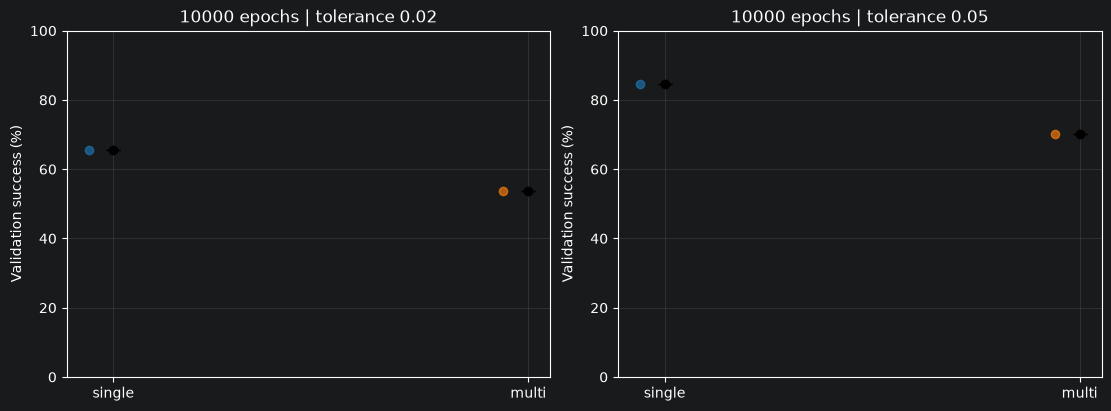

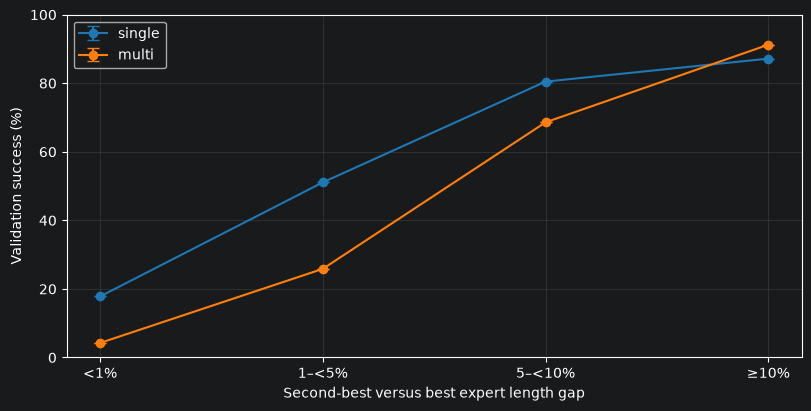

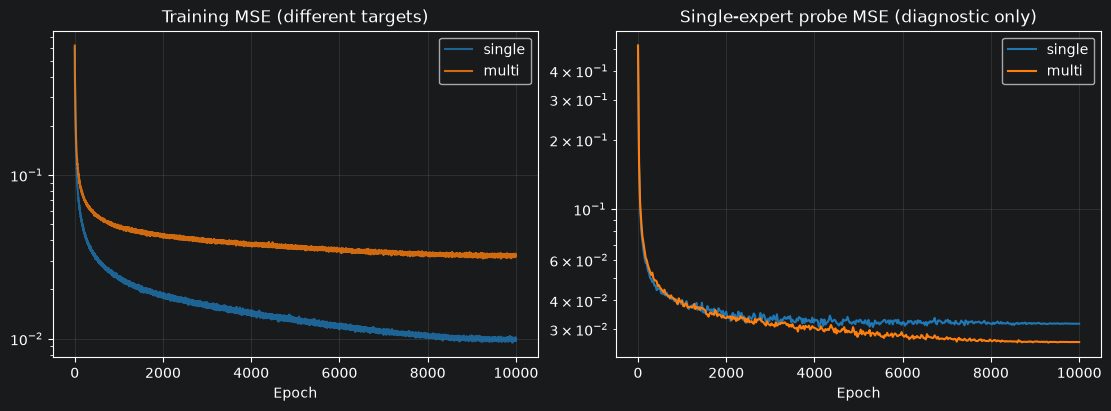

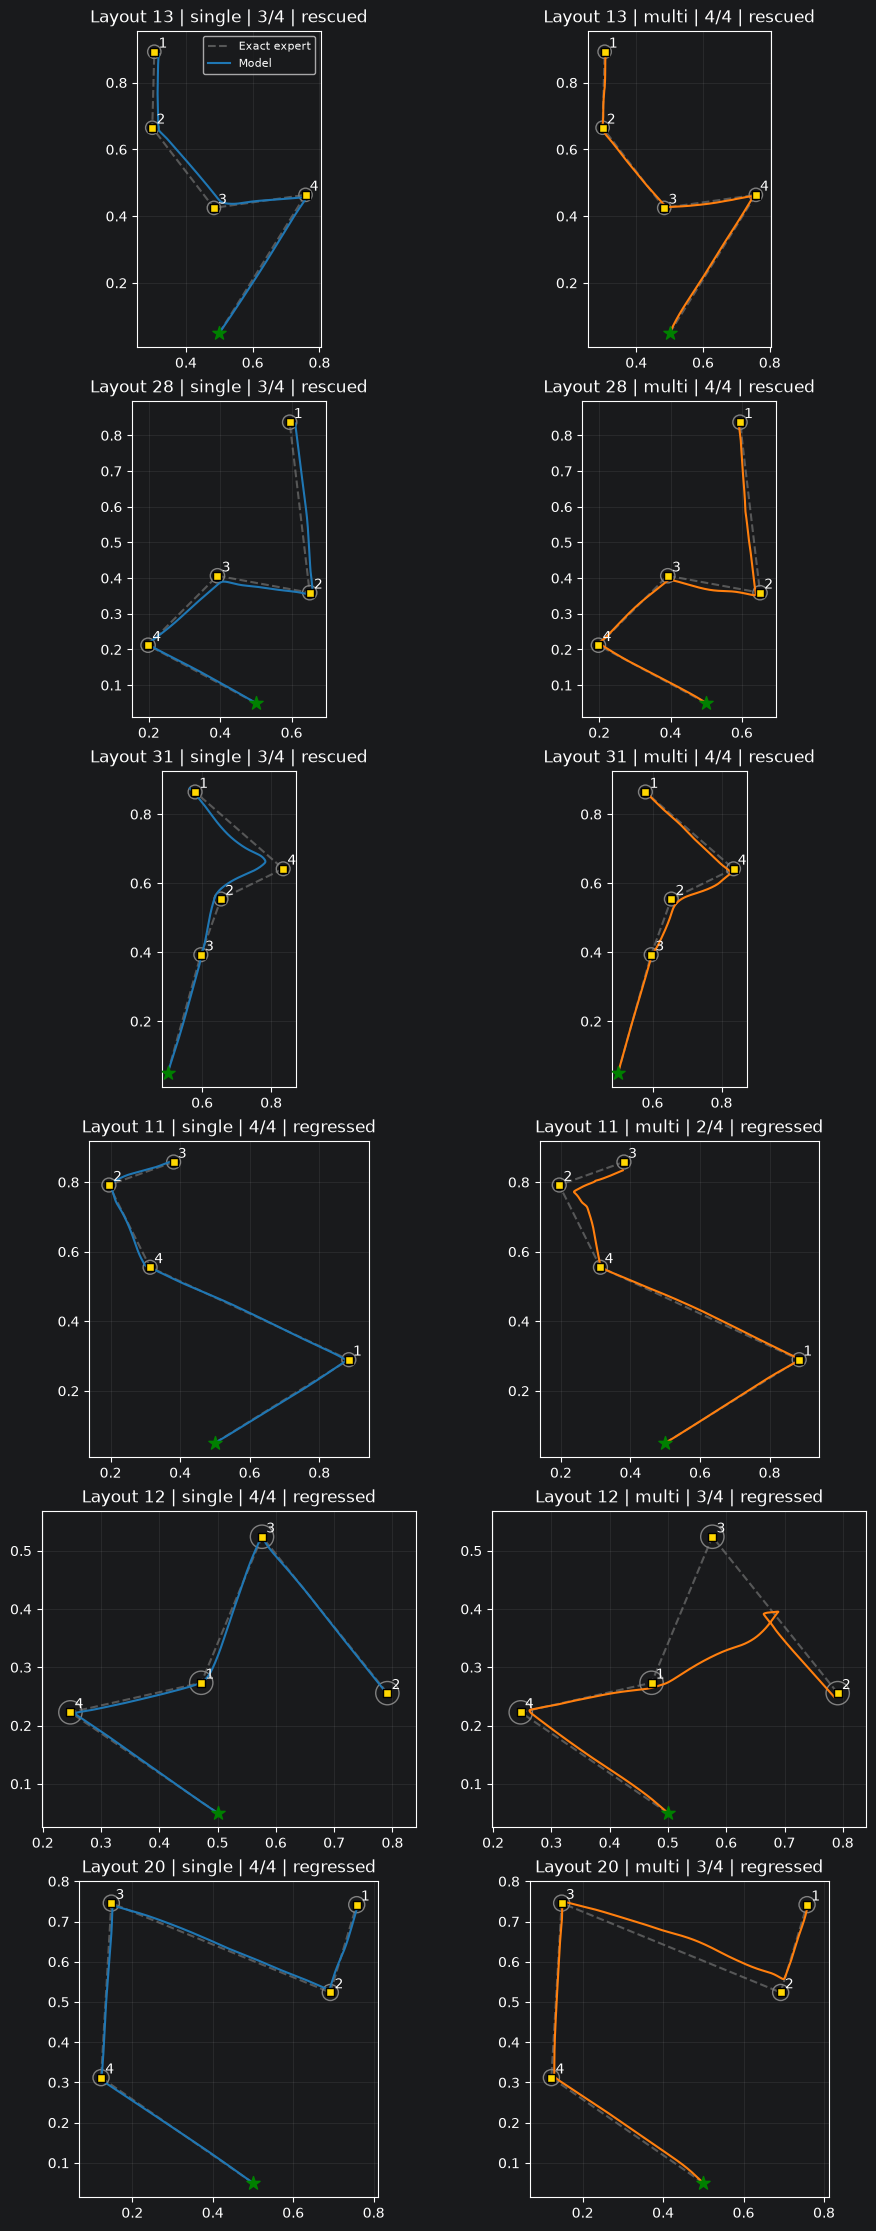

Finished. Main outputs: /home/u7779895/PycharmProjects/streaming-flow-policy_new/experiments/four_boxes_experiments/four_targets/runs/single_vs_multi_05pct_v1/reports/9107258c0f02


In [21]:
colors={'single':'tab:blue','multi':'tab:orange'}
for budget in BUDGETS:
    fig,axes=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
    for ax,tol in zip(axes,[0.02,0.05]):
        for x,mode in enumerate(MODES):
            rows=per_seed[(per_seed.budget==budget)&(per_seed['mode']==mode)&(per_seed.tolerance==tol)&(per_seed.gap_bin=='ALL')]
            y=rows.success_percent.to_numpy()
            ax.scatter(x+np.linspace(-0.06,0.06,len(y)),y,color=colors[mode],alpha=.65)
            ax.errorbar(x,y.mean(),yerr=y.std(ddof=1) if len(y)>1 else 0,fmt='ko',capsize=5)
        ax.set_xticks(range(len(MODES)),MODES)
        ax.set_ylabel('Validation success (%)'); ax.set_ylim(0,100)
        ax.set_title(f'{budget} epochs | tolerance {tol}'); ax.grid(alpha=.2)
    fig.savefig(REPORT_DIR/f'success_{budget}.png',dpi=170); plt.show()
    fig,ax=plt.subplots(figsize=(8,4),constrained_layout=True)
    for mode in MODES:
        g=aggregate[(aggregate.budget==budget)&(aggregate['mode']==mode)&(aggregate.tolerance==0.02)].set_index('gap_bin').reindex(GAP_LABELS)
        ax.errorbar(np.arange(4),g.success_mean_percent,yerr=g.success_sd_pp.fillna(0),fmt='o-',capsize=4,label=mode,color=colors[mode])
    ax.set_xticks(range(4),GAP_LABELS); ax.set_ylim(0,100)
    ax.set_xlabel('Second-best versus best expert length gap')
    ax.set_ylabel('Validation success (%)'); ax.legend(); ax.grid(alpha=.2)
    fig.savefig(REPORT_DIR/f'gap_success_{budget}.png',dpi=170); plt.show()

    fig,axes=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
    for mode in MODES:
        if (budget,PLOT_SEED,mode) not in run_records:
            continue
        ckpt=torch.load(run_records[(budget,PLOT_SEED,mode)]/'final.pt',map_location='cpu',weights_only=True)
        h=ckpt.get('history',{})
        loss=h.get('train_loss',[])
        axes[0].plot(h.get('epoch',list(range(1,len(loss)+1))),loss,label=mode,color=colors[mode],alpha=.8)
        probe=h.get('single_expert_probe_mse',h.get('validation_loss',[]))
        axes[1].plot(h.get('probe_epoch',list(range(1,len(probe)+1))),probe,label=mode,color=colors[mode])
    for ax,title in zip(axes,['Training MSE (different targets)','Single-expert probe MSE (diagnostic only)']):
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_yscale('log'); ax.grid(alpha=.2); ax.legend()
    fig.savefig(REPORT_DIR/f'loss_{budget}_seed_{PLOT_SEED}.png',dpi=170); plt.show()

    if set(MODES)=={'single','multi'} and PLOT_SEED in SEEDS:
        g=paired[(paired.budget==budget)&(paired.seed==PLOT_SEED)&(paired.tolerance==0.02)].sort_values('layout_index')
        improved=g.loc[~g.success_single & g.success_multi,'layout_index'].tolist()
        worsened=g.loc[g.success_single & ~g.success_multi,'layout_index'].tolist()
        chosen=improved[:3]+worsened[:3]
        chosen+=(g.loc[~g.layout_index.isin(chosen),'layout_index'].tolist())[:6-len(chosen)]
        selected_paths={}
        for mode in ['single','multi']:
            with np.load(run_records[(budget,PLOT_SEED,mode)]/'validation_rollouts.npz',allow_pickle=False) as z:
                selected_paths[mode]=z['paths'][chosen]
        fig,axes=plt.subplots(len(chosen),2,figsize=(9,3.7*len(chosen)),squeeze=False,constrained_layout=True)
        example_rows=[]
        for row,i in enumerate(chosen):
            group='rescued' if i in improved else 'regressed' if i in worsened else 'unchanged'
            example_rows.append(dict(layout_index=i,category=group))
            for col,mode in enumerate(['single','multi']):
                ax=axes[row,col]; path=selected_paths[mode][row]; targets=validation['targets'][i]
                expert=validation['routes'][i]; start=validation['starts'][i]
                ax.plot(expert[:,0],expert[:,1],'--',color='gray',alpha=.6,label='Exact expert')
                ax.plot(path[:,0],path[:,1],color=colors[mode],label='Model')
                ax.scatter(*start,marker='*',s=100,color='green',zorder=5)
                ax.scatter(targets[:,0],targets[:,1],marker='s',color='gold',edgecolors='black',zorder=5)
                for j,target in enumerate(targets):
                    ax.add_patch(plt.Circle(target,0.02,fill=False,color='gray'))
                    ax.annotate(str(j+1),target,xytext=(3,3),textcoords='offset points')
                count=int((target_distances(path,targets)<=0.02).sum())
                ax.set_title(f'Layout {i} | {mode} | {count}/4 | {group}')
                # Autoscale includes trajectories outside [0,1]; do not hide runaway paths.
                ax.set_aspect('equal',adjustable='box'); ax.grid(alpha=.15)
        axes[0,0].legend(fontsize=8)
        fig.savefig(REPORT_DIR/f'paired_paths_{budget}_seed_{PLOT_SEED}.png',dpi=150)
        plt.show()
        pd.DataFrame(example_rows).to_csv(REPORT_DIR/f'plotted_layouts_{budget}_seed_{PLOT_SEED}.csv',index=False)
print('Finished. Main outputs:',REPORT_DIR)


## What to send back
运行后请提供 `per_seed_summary.csv`、`across_seed_summary.csv`、`paired_changes.csv` 和
`paired_across_seed_summary.csv`，或对应表格截图；配对路径图也有助于解释改善与退步。

先看 tolerance=0.02、gap_bin=ALL 的成功率，再看 <1% 与 1–<5% 的分组。
如果只跑一个种子，只能作为试验性结果；扩展到五个种子后再讨论稳定性。
较好的结果说明多路线监督在这个任务设置下有帮助，仍不能单独证明原来所有失败都是模式混合造成的。
